ИМПОРТ БИБЛИОТЕК И ПОДКЛЮЧЕНИЕ К БД

In [ ]:
# ===== Импорт библиотек ==========

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка файла для Google Colab
try:
    from google.colab import files
    uploaded_db = files.upload()
    db_name = list(uploaded_db.keys())[0]
    print(f"Файл загружен: {db_name}")
except ImportError:
    db_name = 'mydatabase.db'
    print(f"Работа локально. Файл: {db_name}")

Saving mydatabase.db to mydatabase (7).db
Файл загружен: mydatabase (7).db


In [ ]:
# ===== Подключение к БД ==========

conn = sqlite3.connect(db_name)
print("Подключение к БД установлено")

Подключение к БД установлено



СТАТИСТИКА ПО ТАБЛИЦЕ


In [ ]:
# ===== 1. Общая статистика ==========

df_overall = pd.read_sql_query("""
    SELECT
        COUNT(*) AS total_companies,
        ROUND(AVG(Sales), 2) AS avg_sales,
        ROUND(AVG(Profits), 2) AS avg_profits,
        ROUND(AVG(Assets), 2) AS avg_assets,
        ROUND(AVG(Market_value), 2) AS avg_market_value,
        SUM(Sales) AS total_sales,
        SUM(Profits) AS total_profits,
        SUM(Assets) AS total_assets,
        MIN(Sales) AS min_sales,
        MAX(Sales) AS max_sales,
        MIN(Profits) AS min_profits,
        MAX(Profits) AS max_profits,
        MIN(Assets) AS min_assets,
        MAX(Assets) AS max_assets,
        MIN(Market_value) AS min_market_value,
        MAX(Market_value) AS max_market_value
    FROM top_companies;
""", conn)
print("\n=== ОБЩАЯ СТАТИСТИКА ===\n")
print(df_overall.T)


# ===== 2. Данные по странам ==========

df_country = pd.read_sql_query("""
    SELECT
        Country,
        COUNT(*) AS companies_count,
        ROUND(TOTAL(Sales), 2) AS total_sales,
        ROUND(AVG(Sales), 2) AS avg_sales,
        ROUND(MIN(Sales), 2) AS min_sales,
        ROUND(MAX(Sales), 2) AS max_sales,
        ROUND(TOTAL(Profits), 2) AS total_profits,
        ROUND(AVG(Profits), 2) AS avg_profits,
        ROUND(MIN(Profits), 2) AS min_profits,
        ROUND(MAX(Profits), 2) AS max_profits,
        ROUND(TOTAL(Assets), 2) AS total_assets,
        ROUND(AVG(Assets), 2) AS avg_assets,
        ROUND(MIN(Assets), 2) AS min_assets,
        ROUND(MAX(Assets), 2) AS max_assets
    FROM top_companies
    GROUP BY Country
    ORDER BY total_profits DESC;
""", conn)

df_country.index = range(1, len(df_country) + 1)
print("\n=== ДАННЫЕ ПО СТРАНАМ ===\n")
print(df_country.head())


# ===== 3. Топ-10 компаний по прибыли ==========

df_top10 = pd.read_sql_query("""
    SELECT Rank, Company, Country, Sales, Profits, Assets, Market_value
    FROM top_companies
    ORDER BY Profits DESC
    LIMIT 10;
""", conn)

df_top10.index = range(1, len(df_top10) + 1)
print("\n=== ТОП-10 КОМПАНИЙ ПО ПРИБЫЛИ ===\n")
print(df_top10)




=== ОБЩАЯ СТАТИСТИКА ===

                          0
total_companies     1924.00
avg_sales             19.27
avg_profits            1.23
avg_assets            79.51
avg_market_value      19.56
total_sales        37067.60
total_profits       2358.90
total_assets      152973.00
min_sales              0.00
max_sales            469.20
min_profits          -24.50
max_profits           44.90
min_assets             1.00
max_assets          3226.20
min_market_value       0.00
max_market_value     416.60

=== ДАННЫЕ ПО СТРАНАМ ===

  Country  companies_count  total_sales  avg_sales  min_sales  max_sales  \
1     USA              535      11164.3      20.87        0.2      469.2   
2   China              135       3024.5      22.40        0.8      411.7   
3  Russia               30        710.3      23.68        2.7      144.0   
4      UK               97       2189.2      22.57        0.0      370.9   
5   Japan              246       4636.8      18.85        0.2      224.5   

   total_pro

ПОДГОТОВКА ДАННЫХ ДЛЯ ВИЗУАЛИЗАЦИИ

In [ ]:
# 1. Данные для точечного графика scatter plot
# Cвязь рейтинга и прибыли
# Сортировка компаний по рейтингу (Rank)
df_rank_profit = pd.read_sql_query("""
    SELECT Rank, Company, Country, Profits
    FROM top_companies
    ORDER BY Rank ASC;
""", conn)


# 2. Данные для столбчатой диаграммы bar plot
# Tоп-10 стран по активам
# Сначала получаем агрегированные данные по странам
# Суммируем активы по странам, переводим в миллиарды
# Берем топ-10 стран по активам
df_assets = pd.read_sql_query("""
    SELECT
        Country,
        ROUND(SUM(Assets) / 1000, 2) AS total_assets_billions
    FROM top_companies
    GROUP BY Country
    ORDER BY total_assets_billions DESC
    LIMIT 10;
""", conn)


# 3. Данные для коробчатой диаграммы (ящик с усами) boxplot
# Распределение прибыли по странам
# Берём все данные, а фильтрацию по топ-5 странам сделаем прямо в графике
df_box = pd.read_sql_query("""
    SELECT Country, Profits
    FROM top_companies;
""", conn)


# 4. Данные для круговой диаграммы pie chart
# Доля стран в продажах
df_pie_raw = pd.read_sql_query("""
    SELECT Country, SUM(Sales) AS total_sales
    FROM top_companies
    GROUP BY Country;
""", conn)

# Вычисляем процентное соотношение для фильтрации стран с долей >= 1%
total_sales_all = df_pie_raw['total_sales'].sum()
df_pie_raw['percent'] = df_pie_raw['total_sales'] / total_sales_all * 100

# Оставляем только страны с долей >= 1%
df_pie = df_pie_raw[df_pie_raw['percent'] >= 1].copy()

# Суммируем остальные страны (с долей < 1%) в категорию "Others"
other_sales = df_pie_raw[df_pie_raw['percent'] < 1]['total_sales'].sum()
if other_sales > 0:
    other_row = pd.DataFrame({
        'Country': ['Others'],
        'total_sales': [other_sales],
        'percent': [other_sales / total_sales_all * 100]
    })
    df_pie = pd.concat([df_pie, other_row], ignore_index=True)


# 5. Данные для гистограммы histogram
# Топ-100 компаний по рыночной стоимости ---
# ORDER BY Market_value DESC - сортируем по убыванию
df_market_top100 = pd.read_sql_query("""
    SELECT Market_value
    FROM top_companies
    ORDER BY Market_value DESC
    LIMIT 100;
""", conn)


# 6. Данные для тепловой карты корреляции correlation heatmap
df_corr = pd.read_sql_query("""
    SELECT Sales, Profits, Assets, Market_value
    FROM top_companies;
""", conn)



ВИЗУАЛИЗАЦИЯ

Топ-5 стран в рейтинге:
Country
USA        34
China       9
Germany     8
Japan       7
France      6
Name: count, dtype: int64


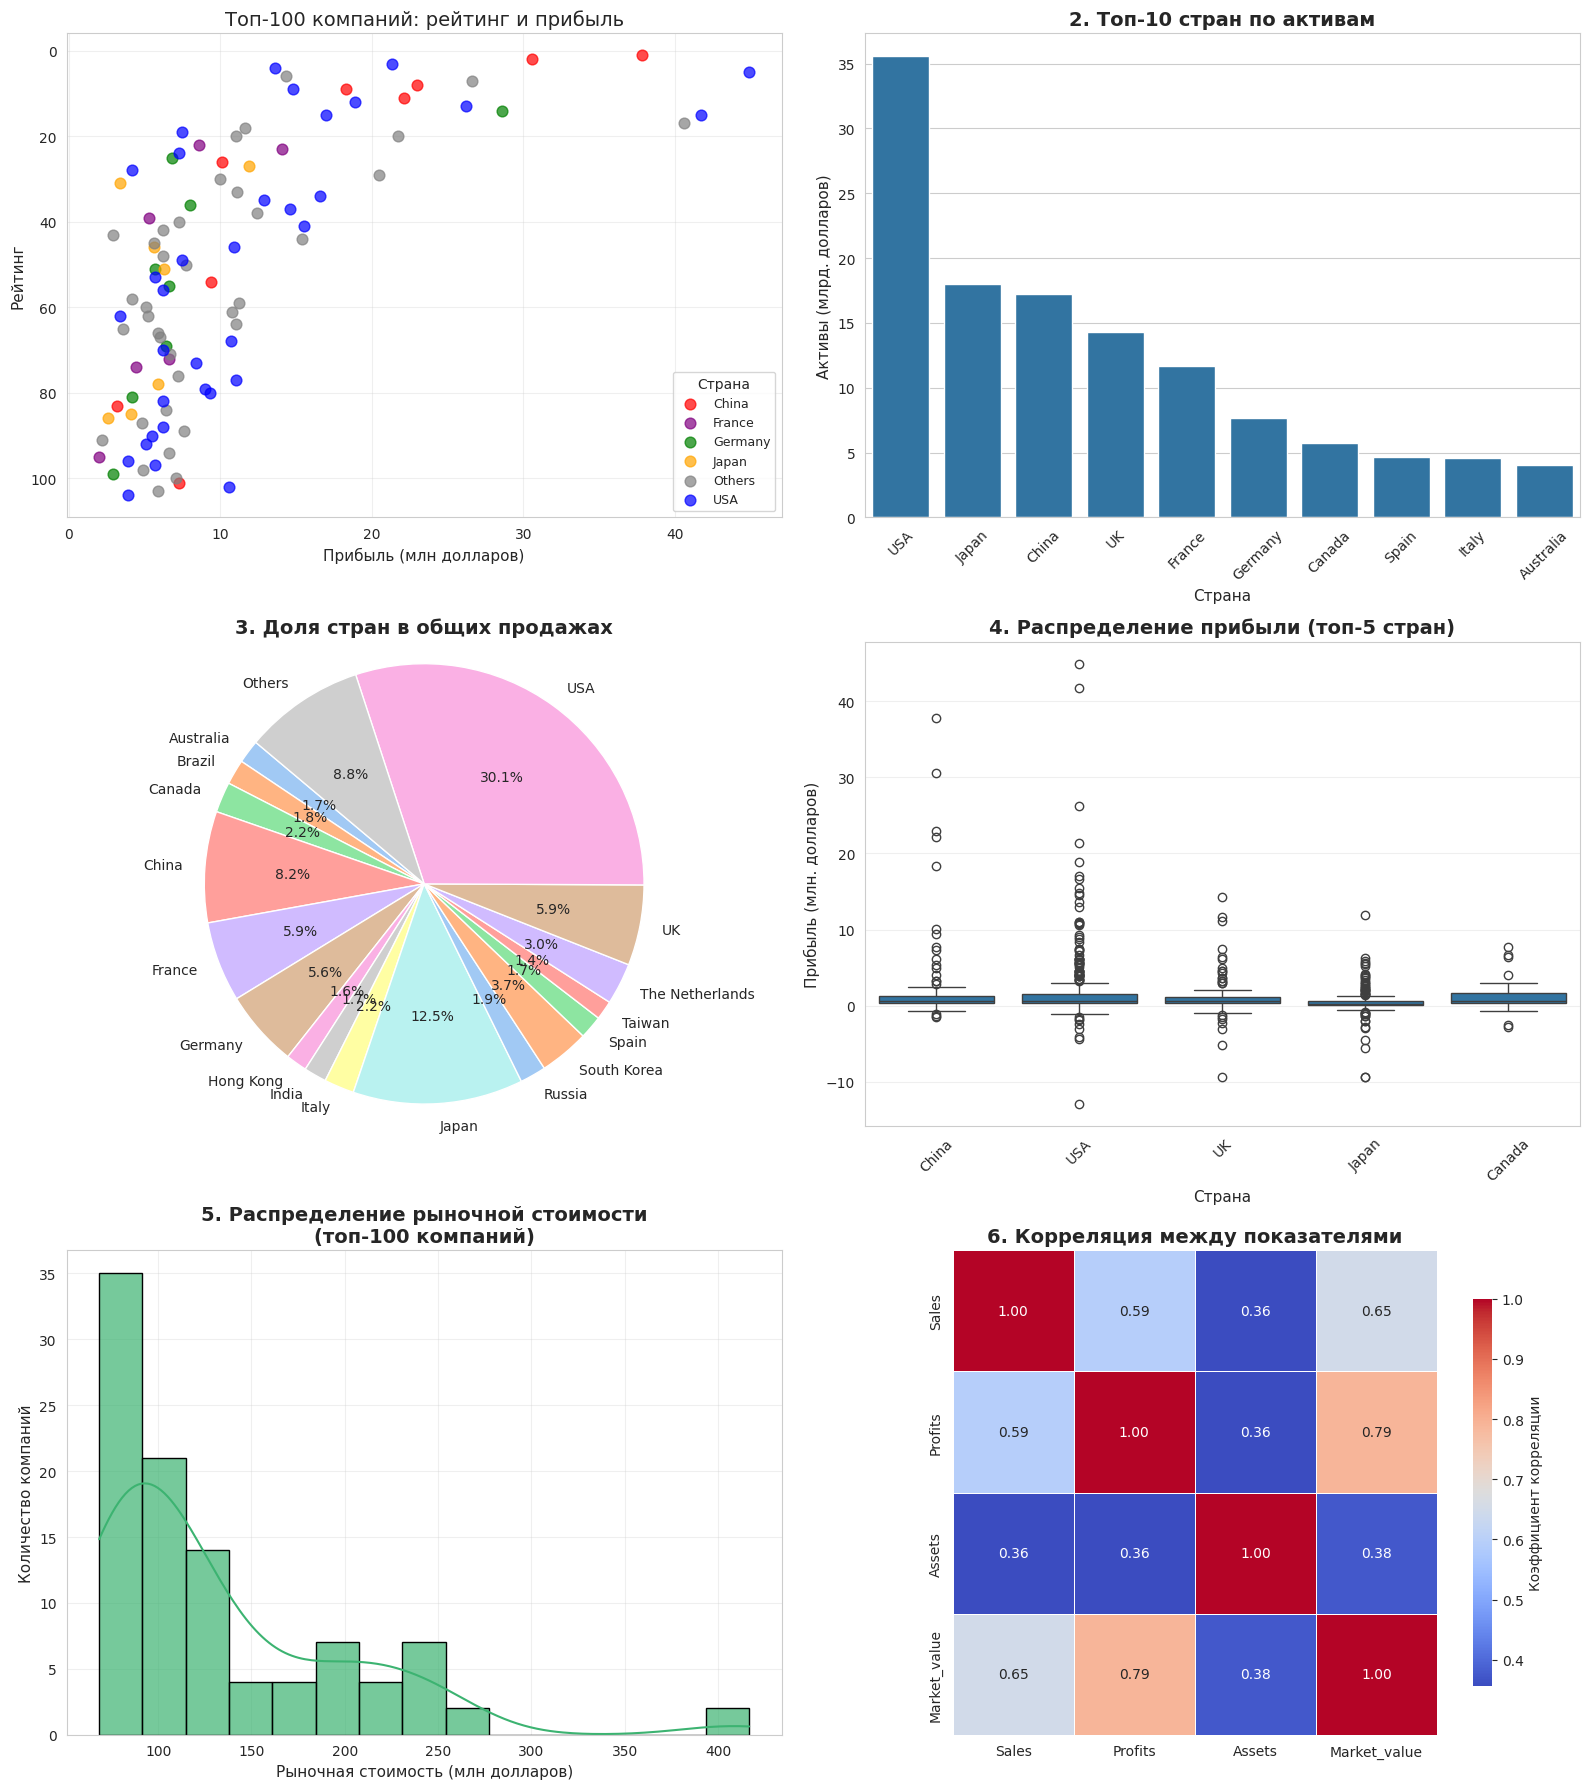

In [ ]:

# ===== Настройка стиля для всех графиков ==========

sns.set_style("whitegrid")        # белый фон и сетка
plt.rcParams['font.size'] = 10    # единый шрифт

# Создаём сетку из 3 строк и 2 столбцов для 6 графиков
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
# Увеличиваем расстояние между графиками, чтобы подписи не накладывались
plt.subplots_adjust(hspace=0.4, wspace=0.3)




# ===== ГРАФИК 1: ТОЧЕЧНЫЙ (Scatter plot) ==========
# Показывает прибыль топ-100 рейтинговых компаний

# Сортировка по рейтингу
df_top100 = df_rank_profit.nsmallest(100, 'Rank').copy()
print("Топ-5 стран в рейтинге:")
print(df_top100['Country'].value_counts().head(5))

# Топ-5 стран и цвета
top5 = df_top100['Country'].value_counts().head(5).index
df_top100['group'] = df_top100['Country'].where(df_top100['Country'].isin(top5), 'Others')
colors = {'USA': 'blue', 'China': 'red', 'Germany': 'green', 'Japan': 'orange', 'France': 'purple', 'Others': 'gray'}

# Параметры вывода
for group, data in df_top100.groupby('group'):
    axes[0, 0].scatter(data['Profits'], data['Rank'],
                       label=group, color=colors.get(group, 'gray'),
                       alpha=0.7, s=60)

# Оформление
axes[0, 0].set_title('Топ-100 компаний: рейтинг и прибыль', fontsize=14)
axes[0, 0].set_xlabel('Прибыль (млн долларов)', fontsize=11)
axes[0, 0].set_ylabel('Рейтинг', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_yaxis()
axes[0, 0].legend(title='Страна', fontsize=9)





# ===== ГРАФИК 2: СТОЛБЧАТАЯ ДИАГРАММА (Bar plot) ==========
# Показывает топ-10 стран по общей сумме продаж

sns.barplot(
    data=df_assets,    # Используем отфильтрованные активы (топ-10 стран)
    x='Country',                # По оси X - названия стран
    y='total_assets_billions',            # По оси Y - общие активы
    ax=axes[0, 1]              # Рисуем во втором подграфике (строка 0, столбец 1)

)
axes[0, 1].set_title('2. Топ-10 стран по активам', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Страна', fontsize=11)
axes[0, 1].set_ylabel('Активы (млрд. долларов)', fontsize=11)
# Поворачиваем подписи на оси X на 45 градусов, чтобы они не слипались
axes[0, 1].tick_params(axis='x', rotation=45)





# ===== ГРАФИК 3: КРУГОВАЯ ДИАГРАММА (Pie chart) ==========
# Показывает долю каждой страны в общих продажах всех компаний

# Страны с долей менее 1% объединены в сектор "Другие"
colors = sns.color_palette('pastel')  # Пастельные цвета для приятного восприятия
axes[1, 0].pie(
    df_pie['total_sales'],      # Значения для построения (продажи)
    labels=df_pie['Country'],   # Подписи секторов (названия стран)
    autopct='%1.1f%%',         # Формат отображения процентов (одна цифра после запятой)
    startangle=140,             # Начальный угол поворота для красивого расположения
    colors=colors,              # Цвета секторов
    textprops={'fontsize': 10}  # Размер шрифта подписей
)
axes[1, 0].set_title('3. Доля стран в общих продажах', fontsize=14, fontweight='bold')
# Для круговой диаграммы делаем оси равными, чтобы круг не превратился в эллипс
axes[1, 0].axis('equal')



# ===== ГРАФИК 4: ЯЩИК С УСАМИ (Boxplot) ==========
# Показывает распределение прибыли по странам (медиана, квартили, выбросы)

# Фильтр топ-5 стран по количеству компаний
top5_countries = df_rank_profit['Country'].value_counts().head(5).index.tolist()
# Создаём временный DataFrame только с этими странами
df_box_filtered = df_box[df_box['Country'].isin(top5_countries)]

sns.boxplot(
    data=df_box_filtered,       # Используем отфильтрованные данные (только топ-5 стран)
    x='Country',                # По оси X - страны
    y='Profits',                # По оси Y - прибыль
    ax=axes[1, 1]              # Рисуем в четвёртом подграфике
)
axes[1, 1].set_title('4. Распределение прибыли (топ-5 стран)',
                     fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Страна', fontsize=11)
axes[1, 1].set_ylabel('Прибыль (млн. долларов)', fontsize=11)
axes[1, 1].tick_params(axis='x', rotation=45)
# Добавляем сетку для лучшей читаемости
axes[1, 1].grid(True, alpha=0.3, axis='y')





# ===== ГРАФИК 5: ГИСТОГРАММА (Histogram) ==========
# Показывает распределение рыночной стоимости среди топ-100 компаний
# сколько компаний в каждом диапазоне стоимости
# KDE (кривая плотности) показывает общий тренд распределения

sns.histplot(
    data=df_market_top100,      # Только топ-100 компаний
    x='Market_value',           # По оси X - рыночная стоимость
    bins=15,                    # Меньше столбцов (для 100 компаний достаточно 15)
    kde=True,                   # Добавляем кривую плотности распределения
    ax=axes[2, 0],              # Рисуем в пятом подграфике
    color='mediumseagreen',     # Цвет
    edgecolor='black',          # Чёрные границы столбцов для чёткости
    alpha=0.7                   # Немного прозрачности
)

# Оформление
axes[2, 0].set_title('5. Распределение рыночной стоимости\n(топ-100 компаний)',
                     fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Рыночная стоимость (млн долларов)', fontsize=11)
axes[2, 0].set_ylabel('Количество компаний', fontsize=11)
axes[2, 0].grid(True, alpha=0.3)





# ===== ГРАФИК 6: ТЕПЛОВАЯ КАРТА КОРРЕЛЯЦИИ (Correlation Heatmap) ==========
# Показывает корреляцию показателей

corr_matrix = df_corr.corr()    # Вычисляем матрицу корреляции

sns.heatmap(
    corr_matrix,                # Матрица корреляции
    annot=True,                 # Показываем числовые значения в ячейках
    cmap='coolwarm',            # Цветовая схема (синий-белый-красный)
    fmt='.2f',                  # Формат чисел (2 знака после запятой)
    linewidths=0.5,             # Толщина линий между ячейками
    ax=axes[2, 1],              # Рисуем в шестом подграфике
    square=True,                # Делаем ячейки квадратными
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'}    # Уменьшаем цветовую шкалу
)
axes[2, 1].set_title('6. Корреляция между показателями',
                     fontsize=14, fontweight='bold')





# ===== ОБЩАЯ НАСТРОЙКА ==========

# Автоматически подгоняем расположение элементов, чтобы ничего не обрезалось
plt.tight_layout()

plt.show()    # Показываем все графики

# Закрываем соединение с базой данных
conn.close()